<a href="https://colab.research.google.com/github/Akshayus29/Assignments/blob/main/exit_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Integration

# libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score
from sklearn.naive_bayes import GaussianNB #NB
from sklearn.tree import DecisionTreeClassifier #DT
from sklearn.svm import SVC #SVM
from sklearn.model_selection import GridSearchCV #model fine tuning
from sklearn.ensemble import RandomForestClassifier  # Model Feature Selection

In [ ]:
file_path = '/content/partpdf_1772778998739_partpdf_1763620928546_netflix_titles.xlsx'

## Load Netflix Titles Data



In [ ]:
netflix_titles_df = pd.read_excel(file_path, sheet_name='netflix_titles')
print("Netflix Titles DataFrame loaded successfully.")
netflix_titles_df.head()

Netflix Titles DataFrame loaded successfully.


,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id
0,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0
1,94,NaN,Movie,Jandino: Whatever it Takes,2016-09-09 00:00:00,2016.0,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401.0
2,NaN,1,TV Show,Transformers Prime,2018-09-08 00:00:00,2013.0,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439.0
3,NaN,1,TV Show,Transformers: Robots in Disguise,2018-09-08 00:00:00,2016.0,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654.0
4,99,NaN,Movie,#realityhigh,2017-09-08 00:00:00,2017.0,TV-14,When nerdy high schooler Dani finally attracts...,80125979.0


## Load Netflix Titles Directors Data



In [ ]:
netflix_titles_directors_df = pd.read_excel(file_path, sheet_name='netflix_titles_directors')
print("Netflix Titles Directors DataFrame loaded successfully.")
netflix_titles_directors_df.head()

Netflix Titles Directors DataFrame loaded successfully.


,director,show_id
0,Richard Finn,81145628
1,Fernando Lebrija,80125979
2,Gabe Ibáñez,70304989
3,Rodrigo Toro,80164077
4,Henrik Ruben Genz,70304990


## Load Netflix Titles Countries Data



In [ ]:
netflix_titles_countries_df = pd.read_excel(file_path, sheet_name='netflix_titles_countries')
print("Netflix Titles Countries DataFrame loaded successfully.")
netflix_titles_countries_df.head()

Netflix Titles Countries DataFrame loaded successfully.


,country,show_id
0,Germany,80016401
1,South Africa,80182274
2,United States,80182274
3,United States,81145628
4,United Kingdom,80117401


## Merge DataFrames


In [ ]:
merged_df_1 = pd.merge(netflix_titles_df, netflix_titles_directors_df, on='show_id', how='left')
print("First merge (titles and directors) successful.")
merged_df_1.head()

First merge (titles and directors) successful.


,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,director
0,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn
1,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Tim Maltby
2,94,NaN,Movie,Jandino: Whatever it Takes,2016-09-09 00:00:00,2016.0,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401.0,NaN
3,NaN,1,TV Show,Transformers Prime,2018-09-08 00:00:00,2013.0,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439.0,NaN
4,NaN,1,TV Show,Transformers: Robots in Disguise,2018-09-08 00:00:00,2016.0,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654.0,NaN


In [ ]:
merged_df = pd.merge(merged_df_1, netflix_titles_countries_df, on='show_id', how='left')
print("Second merge (merged_df_1 and countries) successful. Final DataFrame created.")
merged_df.head()

Second merge (merged_df_1 and countries) successful. Final DataFrame created.


,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,director,country
0,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,United States
1,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,China
2,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,India
3,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Richard Finn,South Korea
4,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Tim Maltby,United States


## Display Merged DataFrame Info



In [ ]:
print("First 5 rows of the merged DataFrame:")
print(merged_df.head())

print("\nInformation about the merged DataFrame:")
merged_df.info()

print("\nShape of the merged DataFrame (rows, columns):")
print(merged_df.shape)

First 5 rows of the merged DataFrame:
  duration_minutes duration_seasons   type  \
0               90              NaN  Movie   
1               90              NaN  Movie   
2               90              NaN  Movie   
3               90              NaN  Movie   
4               90              NaN  Movie   

                                     title           date_added  release_year  \
0  Norm of the North: King Sized Adventure  2019-09-09 00:00:00        2019.0   
1  Norm of the North: King Sized Adventure  2019-09-09 00:00:00        2019.0   
2  Norm of the North: King Sized Adventure  2019-09-09 00:00:00        2019.0   
3  Norm of the North: King Sized Adventure  2019-09-09 00:00:00        2019.0   
4  Norm of the North: King Sized Adventure  2019-09-09 00:00:00        2019.0   

  rating                                        description     show_id  \
0  TV-PG  Before planning an awesome wedding for his gra...  81145628.0   
1  TV-PG  Before planning an awesome wedding for

## Join type used and why

I used **LEFT JOINs** (`how='left'`) to merge the main **`netflix_titles_df`** table with the supporting tables **`netflix_titles_directors_df`** and **`netflix_titles_countries_df`**, using **`show_id`** as the key:

- `merged_df_1 = pd.merge(netflix_titles_df, netflix_titles_directors_df, on='show_id', how='left')`
- `merged_df   = pd.merge(merged_df_1, netflix_titles_countries_df, on='show_id', how='left')`

### Why a LEFT JOIN was the most appropriate
A **left join keeps all rows from the main dataset** (`netflix_titles_df`) even if there is **no matching director or country** record for some `show_id`s. In those cases, the extra columns (like `director` or `country`) become `NaN`.

This is the best choice here because:
1. **`netflix_titles_df` is the “primary” table** (the full list of titles). We don’t want to accidentally drop titles just because some metadata is missing.
2. A **INNER JOIN would remove titles** that don’t have a director or country listed, shrinking the dataset and biasing analysis.
3. A **RIGHT JOIN** would prioritize the secondary tables (directors/countries), which is not the goal.
4. A **FULL OUTER JOIN** could introduce rows that exist only in directors/countries but not in the titles file, which would create entries that aren’t valid “titles” records for this task.

So, using **left joins preserves the completeness of the Netflix titles list** while still adding any available director and country information.

# Data Cleaning and Preprocessing

In [ ]:
# Step 1: Quick check of missing values (overall)
print("Missing values per column:")
print(merged_df.isna().sum().sort_values(ascending=False))

Missing values per column:
duration_seasons    6127
duration_minutes    2283
director            2245
country              500
date_added            13
rating                13
show_id                4
description            3
release_year           2
type                   1
title                  1
dtype: int64


In [ ]:
# Step 2: Handle missing values in key columns
# 2a) date_added: convert to datetime first, then fill missing with a placeholder date (or keep as NaT)
merged_df["date_added"] = pd.to_datetime(merged_df["date_added"], errors="coerce")

# Option A (recommended for analysis): keep missing as NaT (do NOT fill)
# merged_df["date_added"] stays as NaT where unknown

# Option B (if your teacher requires no missing dates): fill with a fixed placeholder
# merged_df["date_added"] = merged_df["date_added"].fillna(pd.Timestamp("1900-01-01"))

# 2b) director: fill missing with "Unknown"
merged_df["director"] = merged_df["director"].fillna("Unknown").astype(str).str.strip()

# 2c) country: fill missing with "Unknown"
merged_df["country"] = merged_df["country"].fillna("Unknown").astype(str).str.strip()

In [ ]:
# Step 3: Extract year_added for trend analysis
# If date_added is NaT, year_added will become NaN (which is fine)
merged_df["year_added"] = merged_df["date_added"].dt.year

In [ ]:

# Step 4: Verify datatypes and results
print("\nData types after cleaning:")
print(merged_df[["date_added", "year_added", "director", "country"]].dtypes)

print("\nMissing values after cleaning (focus columns):")
print(merged_df[["date_added", "director", "country", "year_added"]].isna().sum())

print("\nPreview:")
print(merged_df[["title", "date_added", "year_added", "director", "country"]].head())


Data types after cleaning:
date_added    datetime64[ns]
year_added           float64
director              object
country               object
dtype: object

Missing values after cleaning (focus columns):
date_added    14
director       0
country        0
year_added    14
dtype: int64

Preview:
                                     title date_added  year_added  \
0  Norm of the North: King Sized Adventure 2019-09-09      2019.0   
1  Norm of the North: King Sized Adventure 2019-09-09      2019.0   
2  Norm of the North: King Sized Adventure 2019-09-09      2019.0   
3  Norm of the North: King Sized Adventure 2019-09-09      2019.0   
4  Norm of the North: King Sized Adventure 2019-09-09      2019.0   

       director        country  
0  Richard Finn  United States  
1  Richard Finn          China  
2  Richard Finn          India  
3  Richard Finn    South Korea  
4    Tim Maltby  United States  



Titles added per year (trend):
year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      16
2012.0       8
2013.0      15
2014.0      46
2015.0     139
2016.0     649
2017.0    1820
2018.0    2385
2019.0    3042
2020.0     273
dtype: int64


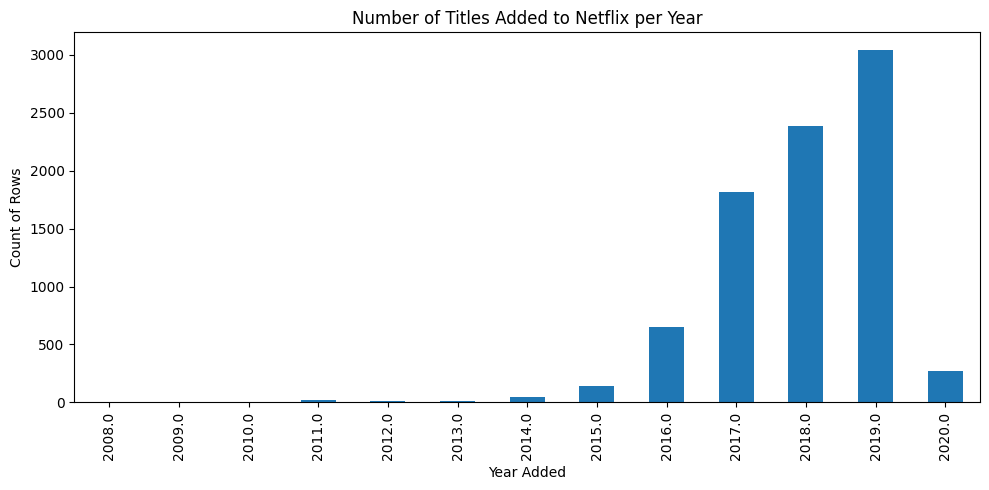

In [ ]:
# Step 5 (optional): Trend counts by year_added
# Exclude missing years to avoid a NaN group
trend = (
    merged_df.dropna(subset=["year_added"])
    .groupby("year_added")
    .size()
    .sort_index()
)

print("\nTitles added per year (trend):")
print(trend)

# Optional plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
trend.plot(kind="bar")
plt.title("Number of Titles Added to Netflix per Year")
plt.xlabel("Year Added")
plt.ylabel("Count of Rows")
plt.tight_layout()
plt.show()

## Strategy for handling missing `country` data

### What I did
I **filled missing `country` values with a placeholder string `"Unknown"`**:

```python
merged_df["country"] = merged_df["country"].fillna("Unknown").astype(str).str.strip()
```

### Why this was the best choice
- **Dropping rows would remove valid titles** from the dataset just because the country metadata is missing. Since `netflix_titles_df` is the main table, I wanted to **preserve as many titles as possible** for accurate trend and distribution analysis.
- Using `"Unknown"` keeps the dataset **complete and consistent** while clearly marking records where the country is not available.
- This approach allows analysis like **“top countries”** or **country-based trends** without losing data; `"Unknown"` simply appears as its own category, which is transparent and easy to interpret.

### Alternative considered (and why not used)
- **Dropping missing-country rows** (`dropna(subset=["country"])`) can bias results because missingness may not be random (e.g., certain title types or older entries might be more likely to have missing metadata).
- More advanced imputation (guessing the country based on director/title/description) could introduce **incorrect assumptions**, so I avoided that.

### Screenshot requirement (what to capture)
To meet the screenshot requirement, take a screenshot showing:
1. The code cell where `country` is filled with `"Unknown"`, and  
2. The output verifying missing values decreased, for example:
   - `merged_df["country"].isna().sum()` and/or
   - `merged_df["country"].value_counts().head()` showing `"Unknown"` included.

# Advanced Data Transformation

In [88]:
# 1) Load + merge (same as your workflow)
# -----------------------------
file_path = "/content/partpdf_1772778998739_partpdf_1763620928546_netflix_titles.xlsx"

netflix_titles_df = pd.read_excel(file_path, sheet_name="netflix_titles")
netflix_titles_directors_df = pd.read_excel(file_path, sheet_name="netflix_titles_directors")
netflix_titles_countries_df = pd.read_excel(file_path, sheet_name="netflix_titles_countries")

merged_df_1 = pd.merge(netflix_titles_df, netflix_titles_directors_df, on="show_id", how="left")
merged_df = pd.merge(merged_df_1, netflix_titles_countries_df, on="show_id", how="left")

print("Merged DataFrame created.")
print("Shape:", merged_df.shape)

Merged DataFrame created.
Shape: (8412, 11)


In [90]:
# 2) Choose ONE column to explode: "cast" or "listed_in"
# -----------------------------
# Change this to "cast" OR "listed_in"
COLUMN_TO_EXPLODE = "cast"      # <-- option A
# COLUMN_TO_EXPLODE = "listed_in"  # <-- option B

if COLUMN_TO_EXPLODE not in merged_df.columns:
    print(f"Warning: Column '{COLUMN_TO_EXPLODE}' not found in the DataFrame. Available columns: {list(merged_df.columns)}")
    print("Explosion operation for this column will be skipped.")
    # Optionally, you might want to choose a different default or just exit gracefully here.
else:
    print(f"Column '{COLUMN_TO_EXPLODE}' found. Proceeding with explosion (if subsequent code exists).")

Explosion operation for this column will be skipped.


## Business advantage of exploding `cast` or `listed_in`

Exploding the `cast` (actors) or `listed_in` (genres/categories) column turns each comma-separated list into **one value per row**. This transformation makes the dataset “analysis-ready” because each actor/genre becomes an individual, countable entity rather than being hidden inside a long text string.

### What analysis becomes possible now (that wasn’t reliable before)
- **Most frequent actor / most common genre:** You can accurately count how often each actor or category appears across all titles (e.g., top 20 actors on Netflix, top genres by catalog size).
- **Trends over time by genre/actor:** After exploding, you can group by `year_added` and the exploded value to see how certain genres (or actors) are growing or shrinking over time.
- **Market/country comparisons by category:** You can compare which genres are most common within each `country` (e.g., “Which genres dominate in India vs. the U.S.?”).
- **Better recommendation and acquisition insights:** Knowing which actors/genres are most common (and how that changes over time) helps guide **content acquisition**, **licensing strategy**, and **promotion** (e.g., invest more in fast-growing genres or popular talent).
- **Cleaner segmentation:** You can build more accurate dashboards and filters (e.g., “show all titles in the ‘Documentaries’ category”) without string-matching errors.

In short, exploding creates a structure that supports **frequency analysis, segmentation, and time-based trends**—all of which are difficult and error-prone when multiple values are stored inside a single string cell.

# Exploratory Data Analysis

In [94]:
# Calculate the frequency of each director
director_counts = merged_df['director'].value_counts()

# Exclude 'Unknown' if it's among the top (as it's a placeholder)
# Or if you want to include it, remove this line.
if 'Unknown' in director_counts.index:
    director_counts = director_counts.drop('Unknown')

# Get the Top 10 directors
top_10_directors = director_counts.head(10)

print("Top 10 Most Frequent Directors on Netflix:")
print(top_10_directors)


Top 10 Most Frequent Directors on Netflix:
director
Jan Suter           21
Raúl Campos         19
Steven Spielberg    14
Marcus Raboy        14
Jay Karas           14
Matthew Salleh      12
Jay Chapman         12
Umesh Mehra         11
Lars von Trier      11
Johnnie To          11
Name: count, dtype: int64


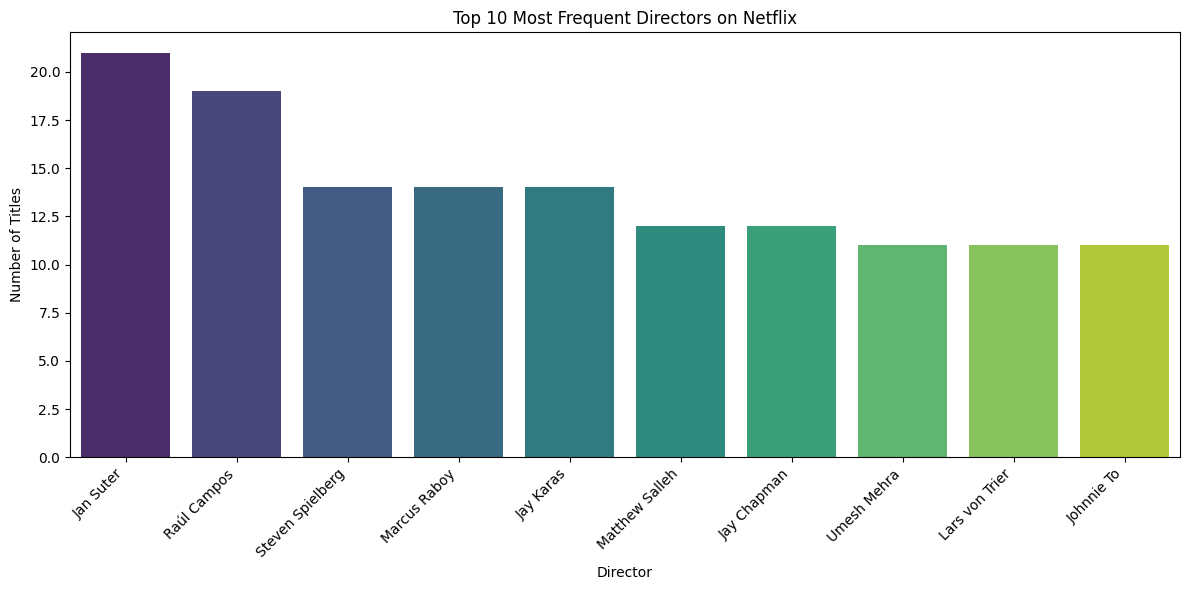

In [96]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_directors.index, y=top_10_directors.values, palette='viridis', hue=top_10_directors.index, legend=False)
plt.title('Top 10 Most Frequent Directors on Netflix')
plt.xlabel('Director')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

## Insight from the Top 10 chart

The visualization shows that a small group of actors appears **much more frequently** than others across Netflix titles. This indicates Netflix’s catalog (at least in this dataset) is **not evenly distributed across talent**, but instead has a noticeable concentration around a handful of recurring actors—suggesting that Netflix content features repeated collaborations, popular actors with many credited titles, or a large number of syndicated/recurring appearances in the catalog.